# PNG to ACL Tear Prediction
This notebook:
1. Loads a PNG image (MRI slice)
2. Preprocesses, compresses, and saves it as `.npz`
3. Loads the trained `best_acl_model_combined.pth` model
4. Runs prediction and displays the result

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

## Step 1: Load PNG and Convert to .npz
Set the path to your PNG file below.

Saved .npz to: input_image.npz
Volume shape: (1, 224, 224), dtype: uint8


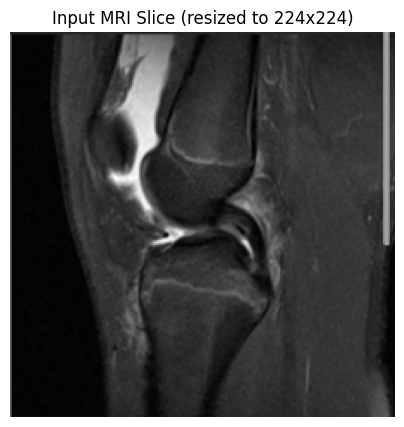

In [34]:
# ===== SET YOUR PNG PATH HERE =====
png_path = r"C:\Users\rickk\OneDrive\Pictures\Screenshots\Screenshot 2026-03-12 175615.png"# <-- Change this to your PNG file path
npz_output_path = "input_image.npz"
TARGET_SIZE = (224, 224)

# Load PNG
img = Image.open(png_path).convert("L")  # Convert to grayscale
img_resized = img.resize(TARGET_SIZE, Image.LANCZOS)
img_array = np.array(img_resized, dtype=np.uint8)  # Shape: (224, 224)

# Wrap as a single-slice volume: shape (1, 224, 224) to match .npz format
volume = img_array[np.newaxis, ...]  # Shape: (1, 224, 224)

# Save as compressed .npz
np.savez_compressed(npz_output_path, data=volume)
print(f"Saved .npz to: {npz_output_path}")
print(f"Volume shape: {volume.shape}, dtype: {volume.dtype}")

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(img_array, cmap='gray')
plt.title("Input MRI Slice (resized to 224x224)")
plt.axis('off')
plt.show()

## Step 2: Load the Trained Model

In [35]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Build model architecture (EfficientNet-B0 with custom classifier)
model = models.efficientnet_b0(weights=None)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(model.classifier[1].in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 2)
)

# Load trained weights
model.load_state_dict(torch.load('best_acl_model_combined.pth', map_location=device))
model.to(device)
model.eval()
print("Model loaded successfully!")

Using device: cpu
Model loaded successfully!


## Step 3: Preprocess the .npz and Run Prediction

In [36]:
import time

# Load the .npz file
volume = np.load(npz_output_path)['data']  # Shape: (num_slices, 224, 224)
print(f"Loaded volume shape: {volume.shape}")

# Process each slice and collect predictions
class_labels = {0: "Normal (No ACL Tear)", 1: "ACL Tear Detected"}
slice_predictions = []
slice_confidences = []

start_time = time.time()

for i in range(volume.shape[0]):
    # Get slice and normalize (same as training pipeline)
    img = volume[i].astype(np.float32) / 255.0
    
    # Per-image z-score normalization
    img_mean = img.mean()
    img_std = img.std() + 1e-8
    img = (img - img_mean) / img_std
    
    # Convert to 3-channel and add batch dimension
    img_tensor = torch.from_numpy(np.stack([img, img, img], axis=0)).unsqueeze(0)  # (1, 3, 224, 224)
    img_tensor = img_tensor.to(device)
    
    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        predicted_class = outputs.argmax(dim=1).item()
        confidence = probs[0, predicted_class].item()
    
    slice_predictions.append(predicted_class)
    slice_confidences.append(confidence)
    print(f"Slice {i}: {class_labels[predicted_class]} (Confidence: {confidence:.2%})")

end_time = time.time()
inference_time = end_time - start_time

# Final prediction (majority vote if multiple slices)
from collections import Counter
final_pred = Counter(slice_predictions).most_common(1)[0][0]
avg_confidence = np.mean([c for p, c in zip(slice_predictions, slice_confidences) if p == final_pred])

print(f"\n{'='*50}")
print(f"FINAL PREDICTION: {class_labels[final_pred]}")
print(f"Average Confidence: {avg_confidence:.2%}")
print(f"Inference Time: {inference_time:.4f}s ({inference_time*1000:.2f} ms)")
print(f"{'='*50}")

Loaded volume shape: (1, 224, 224)
Slice 0: ACL Tear Detected (Confidence: 60.16%)

FINAL PREDICTION: ACL Tear Detected
Average Confidence: 60.16%
Inference Time: 0.0503s (50.30 ms)


## Step 4: Visualize Result

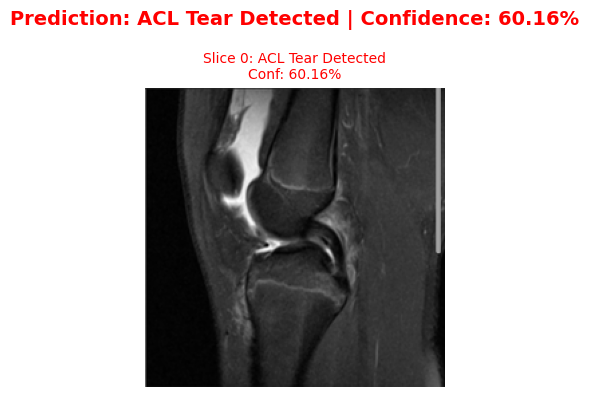

In [37]:
# Display the image with prediction overlay
volume = np.load(npz_output_path)['data']
num_slices = volume.shape[0]
cols = min(num_slices, 5)
rows = (num_slices + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
if num_slices == 1:
    axes = np.array([axes])
axes = np.atleast_2d(axes)

for i in range(num_slices):
    r, c = divmod(i, cols)
    ax = axes[r, c]
    ax.imshow(volume[i], cmap='gray')
    color = 'red' if slice_predictions[i] == 1 else 'green'
    ax.set_title(
        f"Slice {i}: {class_labels[slice_predictions[i]]}\n"
        f"Conf: {slice_confidences[i]:.2%}",
        fontsize=10, color=color
    )
    ax.axis('off')

# Hide unused axes
for i in range(num_slices, rows * cols):
    r, c = divmod(i, cols)
    axes[r, c].axis('off')

fig.suptitle(
    f"Prediction: {class_labels[final_pred]} | Confidence: {avg_confidence:.2%}",
    fontsize=14, fontweight='bold',
    color='red' if final_pred == 1 else 'green'
)
plt.tight_layout()
plt.show()